Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267944  72.306514  70.568518  70.819216  118387200
2020-01-07  71.928055  72.533095  71.708695  72.277578  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200


Root Mean Squared Error: $2.74




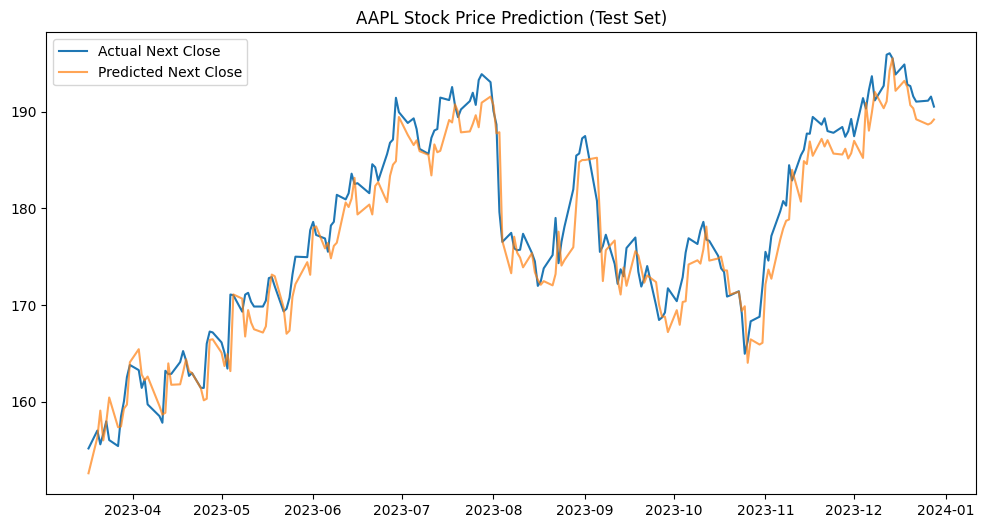

In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Load Data
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01", auto_adjust=True, progress=False)
df.columns = df.columns.get_level_values(0)

# yf.download returns a multi-index dataframe in newer versions, we flatten it for simplicity if needed,
# but usually it's fine for single tickers.

print(df.head())
print("\n")

# 2. Feature Engineering
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['Return_Tomorrow'] = df['Close'].pct_change().shift(-1)  # target: tomorrow's % change
df.dropna(inplace=True)

# 3. Features & Target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'MA_20']
X = df[features]
y = df['Return_Tomorrow']

# 4. Train/Test Split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 5. Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Predict & Convert Back to Price
predictions = model.predict(X_test)
last_prices = df['Close'].iloc[split_idx:].values
predicted_prices = last_prices * (1 + predictions)
actual_prices = last_prices * (1 + y_test.values)

rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
print(f"Root Mean Squared Error: ${rmse:.2f}")
print("\n")

# 7. Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, actual_prices, label='Actual Next Close')
plt.plot(y_test.index, predicted_prices, label='Predicted Next Close', alpha=0.7)
plt.title(f"{ticker} Stock Price Prediction (Test Set)")
plt.legend()
plt.show()